In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

Displacement (min, max) [m]:
  ux: (-1.5516e-01, 0.0000e+00)
  uy: (-1.5516e-01, 0.0000e+00)
  uz: (0.0000e+00, 1.0000e-01)


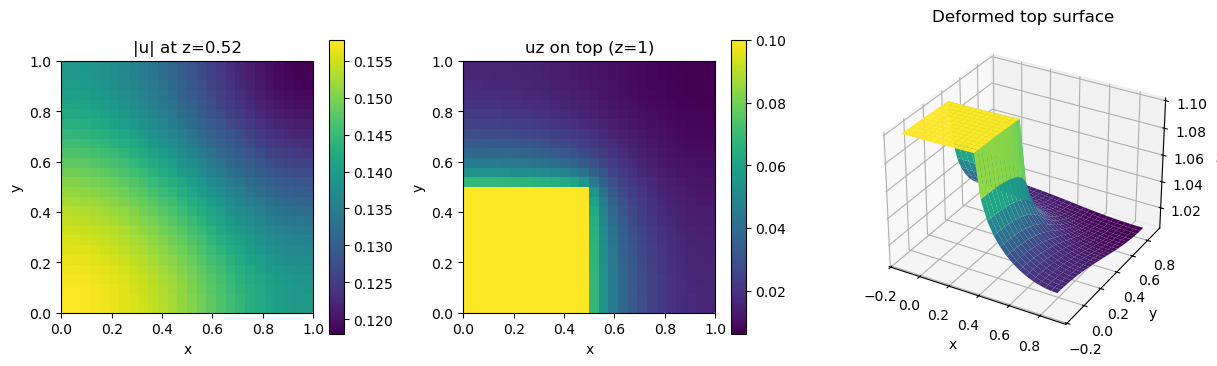

In [4]:
def lame_parameters(E, nu):
    mu = E / (2.0 * (1.0 + nu))
    lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    return lam, mu

def make_grid(nx, ny, nz, Lx=1.0, Ly=1.0, Lz=1.0):
    x = np.linspace(0.0, Lx, nx)
    y = np.linspace(0.0, Ly, ny)
    z = np.linspace(0.0, Lz, nz)
    hx = x[1] - x[0]
    hy = y[1] - y[0]
    hz = z[1] - z[0]
    return x, y, z, hx, hy, hz

def idx(i, j, k, c, nx, ny, nz):
    # c: 0->ux, 1->uy, 2->uz
    return c + 3 * (i + nx * (j + ny * k))

def refl(ii, N):
    # reflective index for zero-normal-derivative at boundary
    if ii < 0:
        return 1
    if ii >= N:
        return N - 2
    return ii

def assemble_matrix_rhs(nx, ny, nz, hx, hy, hz, lam, mu, x, y, z,
                        uz_top=0.1, patch_xmax=0.5, patch_ymax=0.5):
    Nn = nx * ny * nz
    Ndof = 3 * Nn
    rows, cols, data = [], [], []
    b = np.zeros(Ndof)

    lam2 = lam + mu

    def add_entry(r, c, v):
        rows.append(r); cols.append(c); data.append(v)

    # helper to add Laplacian contribution for component p at node (i,j,k)
    def add_laplacian(rrow, i, j, k, p):
        # along x
        i_m = refl(i - 1, nx); i_p = refl(i + 1, nx)
        c_left = idx(i_m, j, k, p, nx, ny, nz)
        c_right = idx(i_p, j, k, p, nx, ny, nz)
        add_entry(rrow, c_left,  mu / (hx * hx))
        add_entry(rrow, c_right, mu / (hx * hx))
        add_entry(rrow, idx(i, j, k, p, nx, ny, nz), -2.0 * mu / (hx * hx))
        # along y
        j_m = refl(j - 1, ny); j_p = refl(j + 1, ny)
        c_down = idx(i, j_m, k, p, nx, ny, nz)
        c_up = idx(i, j_p, k, p, nx, ny, nz)
        add_entry(rrow, c_down,  mu / (hy * hy))
        add_entry(rrow, c_up,    mu / (hy * hy))
        add_entry(rrow, idx(i, j, k, p, nx, ny, nz), -2.0 * mu / (hy * hy))
        # along z
        k_m = refl(k - 1, nz); k_p = refl(k + 1, nz)
        c_b = idx(i, j, k_m, p, nx, ny, nz)
        c_t = idx(i, j, k_p, p, nx, ny, nz)
        add_entry(rrow, c_b,     mu / (hz * hz))
        add_entry(rrow, c_t,     mu / (hz * hz))
        add_entry(rrow, idx(i, j, k, p, nx, ny, nz), -2.0 * mu / (hz * hz))

    # helper to add grad(div u) contribution for component p at node (i,j,k)
    # Using identity: (∇(∇·u))_p = sum_d ∂^2 u_d / (∂x_p ∂x_d)
    # For d == p: pure second derivative along p; for d != p: mixed second derivatives.
    def add_graddiv(rrow, i, j, k, p):
        # map comp index to axis and spacing
        # axis 0->x, 1->y, 2->z
        hs = [hx, hy, hz]
        # pure second derivative term for u_p along axis p
        if p == 0:
            i_m = refl(i - 1, nx); i_p = refl(i + 1, nx)
            add_entry(rrow, idx(i_m, j,   k,   p, nx, ny, nz), lam2 / (hx * hx))
            add_entry(rrow, idx(i_p, j,   k,   p, nx, ny, nz), lam2 / (hx * hx))
            add_entry(rrow, idx(i,   j,   k,   p, nx, ny, nz), -2.0 * lam2 / (hx * hx))
        elif p == 1:
            j_m = refl(j - 1, ny); j_p = refl(j + 1, ny)
            add_entry(rrow, idx(i,   j_m, k,   p, nx, ny, nz), lam2 / (hy * hy))
            add_entry(rrow, idx(i,   j_p, k,   p, nx, ny, nz), lam2 / (hy * hy))
            add_entry(rrow, idx(i,   j,   k,   p, nx, ny, nz), -2.0 * lam2 / (hy * hy))
        else:
            k_m = refl(k - 1, nz); k_p = refl(k + 1, nz)
            add_entry(rrow, idx(i,   j,   k_m, p, nx, ny, nz), lam2 / (hz * hz))
            add_entry(rrow, idx(i,   j,   k_p, p, nx, ny, nz), lam2 / (hz * hz))
            add_entry(rrow, idx(i,   j,   k,   p, nx, ny, nz), -2.0 * lam2 / (hz * hz))

        # mixed derivatives with other components d != p
        # for each pair (p, d) add: ∂^2 u_d / (∂x_p ∂x_d)
        axes = [(0, hx), (1, hy), (2, hz)]
        for d in (0, 1, 2):
            if d == p:
                continue
            hp = hs[p]
            hd = hs[d]
            # four-point stencil: (+p,+d), (+p,-d), (-p,+d), (-p,-d)
            def shift(i, j, k, ax, step):
                if ax == 0:
                    return refl(i + step, nx), j, k
                elif ax == 1:
                    return i, refl(j + step, ny), k
                else:
                    return i, j, refl(k + step, nz)

            # (+p, +d)
            ip, jp, kp = shift(i, j, k, p, +1)
            ipd, jpd, kpd = shift(ip, jp, kp, d, +1)
            add_entry(rrow, idx(ipd, jpd, kpd, d, nx, ny, nz),  lam2 / (4.0 * hp * hd))
            # (+p, -d)
            ip, jp, kp = shift(i, j, k, p, +1)
            imd, jmd, kmd = shift(ip, jp, kp, d, -1)
            add_entry(rrow, idx(imd, jmd, kmd, d, nx, ny, nz), -lam2 / (4.0 * hp * hd))
            # (-p, +d)
            im, jm, km = shift(i, j, k, p, -1)
            impd, jmpd, kmpd = shift(im, jm, km, d, +1)
            add_entry(rrow, idx(impd, jmpd, kmpd, d, nx, ny, nz), -lam2 / (4.0 * hp * hd))
            # (-p, -d)
            im, jm, km = shift(i, j, k, p, -1)
            immd, jmmd, kmmd = shift(im, jm, km, d, -1)
            add_entry(rrow, idx(immd, jmmd, kmmd, d, nx, ny, nz),  lam2 / (4.0 * hp * hd))

    # Assemble
    for k in range(nz):
        for j in range(ny):
            for i in range(nx):
                X, Y, Z = x[i], y[j], z[k]
                # Dirichlet at z=0: fully fixed
                if k == 0:
                    for p in (0, 1, 2):
                        r = idx(i, j, k, p, nx, ny, nz)
                        add_entry(r, r, 1.0)
                        b[r] = 0.0
                    continue

                # Determine if top patch displacement BC applies for uz
                on_top = (k == nz - 1)
                in_patch = (X <= patch_xmax + 1e-12) and (Y <= patch_ymax + 1e-12)

                for p in (0, 1, 2):
                    r = idx(i, j, k, p, nx, ny, nz)

                    # Dirichlet on uz at top patch
                    if p == 2 and on_top and in_patch:
                        add_entry(r, r, 1.0)
                        b[r] = uz_top
                        continue

                    # Otherwise, PDE row
                    add_laplacian(r, i, j, k, p)
                    add_graddiv(r, i, j, k, p)
                    # RHS remains zero (no body forces)

    A = sp.coo_matrix((data, (rows, cols)), shape=(Ndof, Ndof)).tocsr()
    return A, b

def solve_system(A, b, use_cg=True, tol=1e-8, maxiter=2000):
    if not use_cg:
        return spla.spsolve(A, b)
    # CG with optional ILU preconditioner
    try:
        ilu = spla.spilu(A.tocsc(), drop_tol=1e-3, fill_factor=10)
        M = spla.LinearOperator(A.shape, ilu.solve)
    except Exception:
        M = None
    u, info = spla.cg(A, b, tol=tol, maxiter=maxiter, M=M)
    if info != 0:
        raise RuntimeError(f"CG did not converge, info={info}")
    return u

def compute_strain_stress(u, nx, ny, nz, hx, hy, hz, lam, mu):
    # reshape displacement components
    ux = u[0::3].reshape((nx, ny, nz), order='F')
    uy = u[1::3].reshape((nx, ny, nz), order='F')
    uz = u[2::3].reshape((nx, ny, nz), order='F')

    def d_dx(f):
        # central differences with reflection at boundaries
        df = np.empty_like(f)
        f_m = np.take(f, indices=np.arange(-1, nx-1), axis=0, mode='wrap')
        f_p = np.take(f, indices=np.arange(1, nx+1), axis=0, mode='wrap')
        # Replace wrapped edges with reflection
        f_m[0, :, :] = f[1, :, :]
        f_p[-1, :, :] = f[-2, :, :]
        df = (f_p - f_m) / (2.0 * hx)
        return df

    def d_dy(f):
        df = np.empty_like(f)
        f_m = np.take(f, indices=np.arange(-1, ny-1), axis=1, mode='wrap')
        f_p = np.take(f, indices=np.arange(1, ny+1), axis=1, mode='wrap')
        f_m[:, 0, :] = f[:, 1, :]
        f_p[:, -1, :] = f[:, -2, :]
        df = (f_p - f_m) / (2.0 * hy)
        return df

    def d_dz(f):
        df = np.empty_like(f)
        f_m = np.take(f, indices=np.arange(-1, nz-1), axis=2, mode='wrap')
        f_p = np.take(f, indices=np.arange(1, nz+1), axis=2, mode='wrap')
        f_m[:, :, 0] = f[:, :, 1]
        f_p[:, :, -1] = f[:, :, -2]
        df = (f_p - f_m) / (2.0 * hz)
        return df

    # strains
    exx = d_dx(ux)
    eyy = d_dy(uy)
    ezz = d_dz(uz)
    exy = 0.5 * (d_dy(ux) + d_dx(uy))
    exz = 0.5 * (d_dz(ux) + d_dx(uz))
    eyz = 0.5 * (d_dz(uy) + d_dy(uz))

    # stresses
    tr = exx + eyy + ezz
    sxx = 2 * mu * exx + lam * tr
    syy = 2 * mu * eyy + lam * tr
    szz = 2 * mu * ezz + lam * tr
    sxy = 2 * mu * exy
    sxz = 2 * mu * exz
    syz = 2 * mu * eyz

    return ux, uy, uz, (exx, eyy, ezz, exy, exz, eyz), (sxx, syy, szz, sxy, sxz, syz)

def visualize(x, y, z, ux, uy, uz, szz=None, scale=1.0):
    nx, ny, nz = len(x), len(y), len(z)

    # Displacement magnitude on mid-plane z slice
    k_mid = nz // 2
    Umag = np.sqrt(ux[:, :, k_mid]**2 + uy[:, :, k_mid]**2 + uz[:, :, k_mid]**2)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title(f'|u| at z={z[k_mid]:.2f}')
    im = plt.imshow(Umag.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], aspect='equal')
    plt.xlabel('x'); plt.ylabel('y'); plt.colorbar(im, shrink=0.8)

    # uz on top surface
    plt.subplot(1, 3, 2)
    plt.title('uz on top (z=1)')
    im2 = plt.imshow(uz[:, :, -1].T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], aspect='equal')
    plt.xlabel('x'); plt.ylabel('y'); plt.colorbar(im2, shrink=0.8)

    # 3D deformed top surface
    X, Y = np.meshgrid(x, y, indexing='ij')
    Z = np.ones_like(X) * z[-1]
    Xd = X + scale * ux[:, :, -1]
    Yd = Y + scale * uy[:, :, -1]
    Zd = Z + scale * uz[:, :, -1]

    ax = plt.subplot(1, 3, 3, projection='3d')
    ax.plot_surface(Xd, Yd, Zd, facecolors=None, rstride=1, cstride=1,
                    cmap='viridis', linewidth=0.2, antialiased=True,
                    shade=True)
    ax.set_title('Deformed top surface')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

    plt.tight_layout()
    plt.show()

def main():
    # Problem parameters
    E = 3.0e6         # Pa
    nu = 0.4
    lam, mu = lame_parameters(E, nu)

    # Grid
    nx, ny, nz = 26, 26, 26  # adjust for accuracy/performance
    x, y, z, hx, hy, hz = make_grid(nx, ny, nz)

    # Assemble linear system
    A, b = assemble_matrix_rhs(nx, ny, nz, hx, hy, hz, lam, mu, x, y, z,
                               uz_top=0.1, patch_xmax=0.5, patch_ymax=0.5)

    # Solve
    u = solve_system(A, b, use_cg=False)

    # Post-process: displacement, strain, stress
    ux, uy, uz, strains, stresses = compute_strain_stress(u, nx, ny, nz, hx, hy, hz, lam, mu)

    # Report basic stats
    print('Displacement (min, max) [m]:')
    print(f'  ux: ({ux.min():.4e}, {ux.max():.4e})')
    print(f'  uy: ({uy.min():.4e}, {uy.max():.4e})')
    print(f'  uz: ({uz.min():.4e}, {uz.max():.4e})')

    # Visualize
    visualize(x, y, z, ux, uy, uz, scale=1.0)

if __name__ == "__main__":
    main()